<a href="https://colab.research.google.com/github/SaniyaIrfan1113/MachineLearningProjects/blob/main/8_Random_Forest_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

Upload Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving studentscores.csv to studentscores.csv


Read Dataset

In [ ]:
dataset = pd.read_csv("studentscores.csv")

In [ ]:
dataset.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


Explore Dataset

In [ ]:
dataset.shape

(25, 2)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [ ]:
dataset.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [ ]:
dataset.isnull().sum()

,0
Hours,0
Scores,0


Select Features

In [ ]:
X = dataset.iloc[:, :-1].values

In [ ]:
Y = dataset.iloc[:, 1].values

In [ ]:
print(X[:5])
print(Y[:5])

[[2.5]
 [5.1]
 [3.2]
 [8.5]
 [3.5]]
[21 47 27 75 30]


Split Dataset

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.25,
    random_state=0
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(18, 1)
(7, 1)


Create Random Forest Regression Model

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=0
)

Train Model

In [ ]:
model.fit(X_train, Y_train)

RandomForestRegressor(random_state=0)

Predict Test Data

In [ ]:
Y_pred = model.predict(X_test)

In [ ]:
print(Y_pred)

[19.61       37.1525     84.64       24.84333333 63.76       34.67
 20.81      ]


Compare Actual vs Predicted

In [ ]:
comparison = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": Y_pred
})

comparison

,Actual,Predicted
0,20,19.610000
1,27,37.152500
2,69,84.640000
3,30,24.843333
4,62,63.760000
5,35,34.670000
6,24,20.810000


Calculate Mean Squared Error (MSE)

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 55.401252480158746


Calculate R² Score

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, Y_pred)

print("R² Score:", r2)

R² Score: 0.8277061835790951


Predict New Student Score

In [ ]:
new_hours = [[9.25]]

prediction = model.predict(new_hours)

print("Predicted Score:", prediction)

Predicted Score: [88.92]


Visualize Regression Results

/tmp/ipykernel_1798/3090838118.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


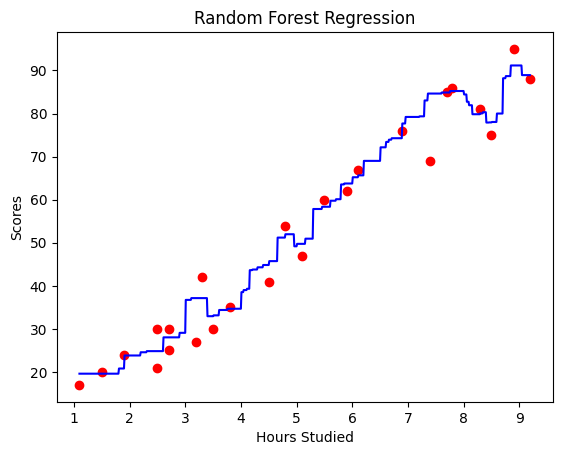

In [ ]:
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.scatter(X, Y, color="red")
plt.plot(X_grid, model.predict(X_grid), color="blue")

plt.title("Random Forest Regression")
plt.xlabel("Hours Studied")
plt.ylabel("Scores")

plt.show()

Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": ["Hours"],
    "Importance": model.feature_importances_
})

importance

,Feature,Importance
0,Hours,1.0


Save Model

In [ ]:
import joblib

joblib.dump(model, "random_forest_regressor.pkl")

['random_forest_regressor.pkl']

In [ ]:
loaded_model = joblib.load("random_forest_regressor.pkl")

09_Random_Forest_Regression.ipynb

1. Import Libraries
2. Upload Dataset
3. Read Dataset
4. Explore Dataset
5. Select Features
6. Split Dataset
7. Create Random Forest Regression Model
8. Train Model
9. Predict Test Data
10. Compare Actual vs Predicted
11. Mean Squared Error (MSE)
12. R² Score
13. Predict New Student Score
14. Visualize Regression Results
15. Feature Importance
16. Save Model